In [1]:
# ============================================================================
# SECTION 01: IMPORTS & PROJECT SETUP
# ============================================================================

import sys
from pathlib import Path

# Add project root to Python path
# This goes UP one level from notebooks/ to the project root where src/ is located
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

print(f"✓ Project root added to path: {project_root}")
print(f"✓ Current working directory: {notebook_dir}")

# Now import custom modules
from src.preprocessing import DataPreprocessor
from src.feature_engineering import FeatureEngineer
from src.visualization import Visualizer
from src.models import ModelTrainer
from src.evaluation import ModelEvaluator
from src.utils import (create_timestamp, save_json, create_model_metadata,
                       print_section_header, print_subsection_header)

import joblib
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("✓ All imports successful")
timestamp = create_timestamp()

✓ Project root added to path: d:\Projects\ba-predictive-analytics
✓ Current working directory: d:\Projects\ba-predictive-analytics\notebooks
✓ All imports successful


In [2]:
# ============================================================================
# SECTION 01: IMPORTS & PROJECT SETUP
# ============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
import sys
sys.path.append('src')

from src.preprocessing import DataPreprocessor
from src.feature_engineering import FeatureEngineer
from src.visualization import Visualizer
from src.models import ModelTrainer
from src.evaluation import ModelEvaluator
from src.utils import (create_timestamp, save_json, create_model_metadata,
                       print_section_header, print_subsection_header)

import joblib
from pathlib import Path

print("✓ All imports successful")
timestamp = create_timestamp()

✓ All imports successful


In [3]:
# ============================================================================
# SECTION 02: LOAD DATASET
# ============================================================================

print_section_header("LOADING DATASET")

# Load data
df = pd.read_csv('https://raw.githubusercontent.com/beingAnujChaudhary/ba-predictive-analytics/main/data/raw/secondTask/customer_booking.csv', encoding='ISO-8859-1')

print(f"✓ Dataset loaded successfully")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


LOADING DATASET
✓ Dataset loaded successfully
  Shape: 50,000 rows × 14 columns
  Memory: 16.74 MB


In [4]:
# ============================================================================
# SECTION 03: DATASET OVERVIEW
# ============================================================================

print_section_header("DATASET OVERVIEW")

print("\n📋 First 5 rows:")
display(df.head())


DATASET OVERVIEW

📋 First 5 rows:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [5]:
print("\n📊 Data types:")
print(df.dtypes)


📊 Data types:
num_passengers             int64
sales_channel                str
trip_type                    str
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                   str
route                        str
booking_origin               str
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object


In [6]:
print("\n🔍 Missing values:")
missing = df.isnull().sum()
print(missing[missing > 0])


🔍 Missing values:
Series([], dtype: int64)


In [7]:

print("\n📈 Statistical summary:")
display(df.describe())


📈 Statistical summary:


,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [8]:
# ============================================================================
# SECTION 04: MISSING VALUES ANALYSIS
# ============================================================================

print_section_header("MISSING VALUES ANALYSIS")

# Calculate missing percentage
missing_df = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

print(missing_df[missing_df['Missing'] > 0])


MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Missing, Percentage]
Index: []



TARGET DISTRIBUTION

📊 Creating target distribution plot...
  ✓ Saved to ..\outputs\figures\01_target_distribution.png


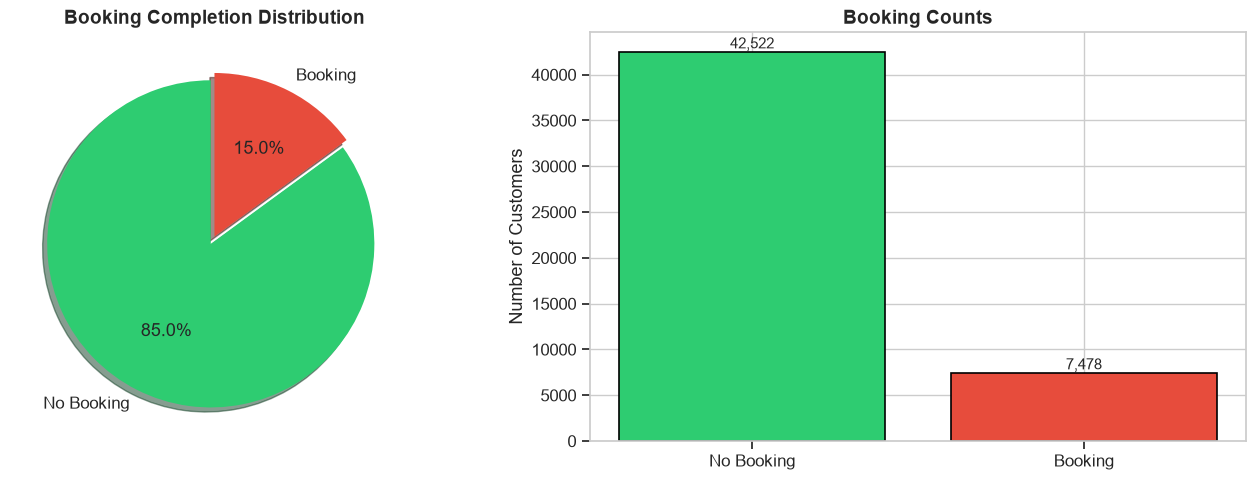

In [9]:
# ============================================================================
# SECTION 05: TARGET DISTRIBUTION
# ============================================================================

print_section_header("TARGET DISTRIBUTION")

viz = Visualizer(output_dir='../outputs/figures')
viz.plot_target_distribution(df['booking_complete'], save=True, show=True)


📊 Creating correlation heatmap...


  ✓ Saved to ..\outputs\figures\02_correlation_heatmap.png


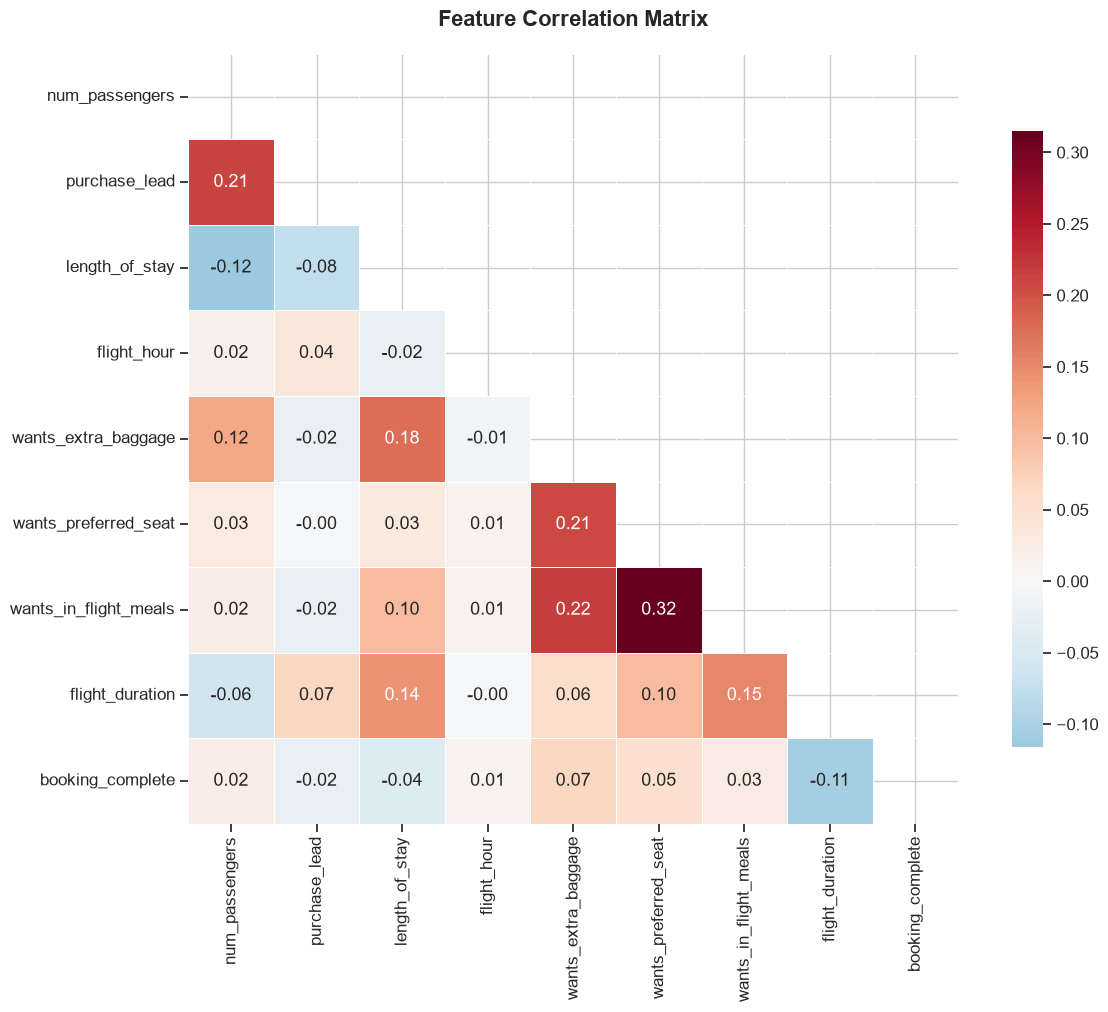

In [10]:
# ============================================================================
# SECTION 06: CORRELATION HEATMAP
# ============================================================================

viz.plot_correlation_heatmap(df, save=True, show=True)

In [11]:
# ============================================================================
# SECTION 07: FEATURE ENGINEERING
# ============================================================================

print_section_header("FEATURE ENGINEERING")

engineer = FeatureEngineer()
df_engineered = engineer.create_features(df)

print(f"\n✓ Total features after engineering: {df_engineered.shape[1]}")


FEATURE ENGINEERING
🔧 Creating new features...
  ✓ Created route_complexity
  ✓ Created is_long_haul
  ✓ Created lead_time_category
  ✓ Created stay_category
  ✓ Created is_weekend
  ✓ Created add_ons
  ✓ Created is_peak_hour
  ✓ Created price_sensitivity

  Total new features created: 8

✓ Total features after engineering: 22


In [12]:
# ============================================================================
# SECTION 08: ENCODING CATEGORICAL VARIABLES
# ============================================================================

print_section_header("ENCODING CATEGORICAL VARIABLES")

preprocessor = DataPreprocessor()
df_encoded = preprocessor.encode_categorical(
    df_engineered, 
    categorical_cols=['sales_channel', 'trip_type', 'flight_day']
)


ENCODING CATEGORICAL VARIABLES
🔧 Encoding categorical variables...
  ✓ Encoded sales_channel: 2 categories
  ✓ Encoded trip_type: 3 categories
  ✓ Encoded flight_day: 7 categories


In [13]:
# ============================================================================
# SECTION 09: PREPARE FEATURES
# ============================================================================

print_section_header("PREPARING FEATURES")

X, y = preprocessor.prepare_features(df_encoded, target_col='booking_complete')

print(f"\n✓ Feature matrix: {X.shape}")
print(f"✓ Target vector: {y.shape}")


PREPARING FEATURES
🔧 Preparing features...
  ✓ Features: 21 columns
  ✓ Numerical: 17
  ✓ Categorical: 2

✓ Feature matrix: (50000, 21)
✓ Target vector: (50000,)


In [14]:
# ============================================================================
# SECTION 9.5: ENCODE ALL REMAINING CATEGORICAL VARIABLES (CRITICAL FIX)
# ============================================================================

print_section_header("ENCODING REMAINING CATEGORICAL VARIABLES")

# SMOTE requires purely numerical data. We must ensure NO string columns remain.
# Identify any remaining categorical columns (like 'route' and 'booking_origin')
remaining_cat_cols = X.select_dtypes(include=['object', 'category']).columns

print(f"Remaining categorical columns found: {list(remaining_cat_cols)}")

if len(remaining_cat_cols) > 0:
    # One-Hot Encode remaining categorical variables
    # drop_first=True prevents the dummy variable trap for linear models
    X = pd.get_dummies(X, columns=remaining_cat_cols, drop_first=True, dtype=int)
    print(f"✓ One-Hot Encoding applied successfully.")
    print(f"✓ New feature matrix shape: {X.shape}")
else:
    print("✓ No remaining categorical columns found. Data is purely numerical.")

# Update the list of numerical columns for the scaler
preprocessor.numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"✓ Updated numerical columns for scaling: {len(preprocessor.numerical_cols)} features")


ENCODING REMAINING CATEGORICAL VARIABLES
Remaining categorical columns found: ['route', 'booking_origin', 'lead_time_category', 'stay_category']
✓ One-Hot Encoding applied successfully.
✓ New feature matrix shape: (50000, 925)
✓ Updated numerical columns for scaling: 925 features


In [15]:
# ============================================================================
# SECTION 10: TRAIN/TEST SPLIT
# ============================================================================

print_section_header("TRAIN/TEST SPLIT")

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"✓ Training set: {X_train.shape[0]:,} samples")
print(f"✓ Test set: {X_test.shape[0]:,} samples")


TRAIN/TEST SPLIT
✓ Training set: 37,500 samples
✓ Test set: 12,500 samples


In [16]:
# ============================================================================
# SECTION 11: SCALE FEATURES
# ============================================================================

print_section_header("SCALING FEATURES")

X_train_scaled, X_test_scaled = preprocessor.scale_features(
    X_train, X_test
)


SCALING FEATURES
🔧 Scaling numerical features...
  ✓ Scaled 925 numerical columns


In [17]:
# ============================================================================
# SECTION 12: APPLY SMOTE
# ============================================================================

print_section_header("APPLYING SMOTE")

X_train_resampled, y_train_resampled = preprocessor.apply_smote(
    X_train_scaled, y_train
)


APPLYING SMOTE
🔧 Applying SMOTE to balance classes...
  ✓ Before SMOTE: 37500 samples
  ✓ After SMOTE: 63782 samples
  ✓ Class distribution: {np.int64(0): np.int64(31891), np.int64(1): np.int64(31891)}


In [18]:
# ============================================================================
# SECTION 13: TRAIN LOGISTIC REGRESSION
# ============================================================================

print_section_header("TRAINING LOGISTIC REGRESSION")

trainer = ModelTrainer(models_dir='../models')

lr_model = trainer.train_logistic_regression(
    X_train_resampled, y_train_resampled, tune=False
)


TRAINING LOGISTIC REGRESSION

TRAINING LOGISTIC REGRESSION
✓ Logistic Regression trained successfully


In [19]:
# ============================================================================
# SECTION 14: EVALUATE LOGISTIC REGRESSION
# ============================================================================

print_section_header("EVALUATING LOGISTIC REGRESSION")

evaluator = ModelEvaluator(output_dir='../outputs/reports')

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
lr_metrics = evaluator.calculate_metrics(y_test, lr_pred, lr_proba)

# Cross-validation
lr_cv = evaluator.cross_validate(lr_model, X_train_resampled, y_train_resampled)

# Print metrics
evaluator.print_metrics(lr_metrics, lr_cv)


EVALUATING LOGISTIC REGRESSION

MODEL PERFORMANCE METRICS
Accuracy            : 0.7146
Precision           : 0.3072
Recall              : 0.7239
F1 Score            : 0.4314
Roc Auc             : 0.7747

Cross-Validation ROC-AUC: 0.8265 (+/- 0.0217)



📊 Creating ROC curve for Logistic Regression...
  ✓ Saved to ..\outputs\figures\04_roc_curve_logistic_regression.png


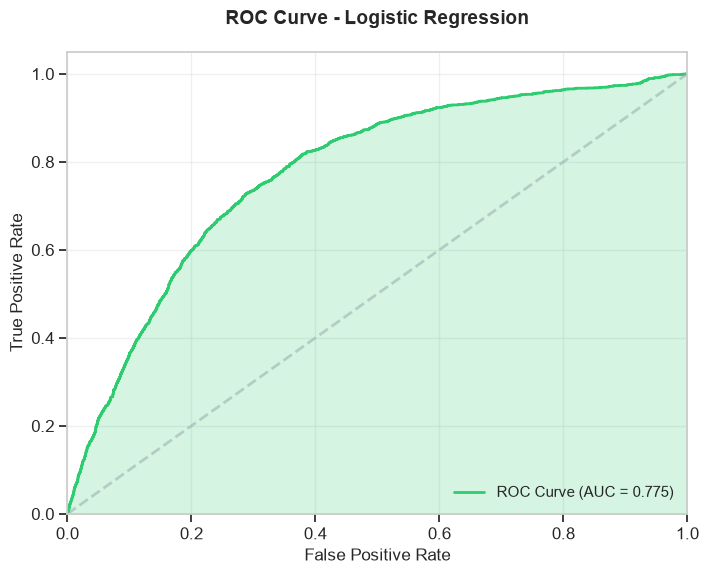

0.7747196069280412

In [25]:
# ============================================================================
# SECTION 15: ROC CURVE - LOGISTIC REGRESSION
# ============================================================================

viz.plot_roc_curve(y_test, lr_proba, 'Logistic Regression', save=True, show=True)


📊 Creating confusion matrix for Logistic Regression...
  ✓ Saved to ..\outputs\figures\03_confusion_matrix_logistic_regression.png


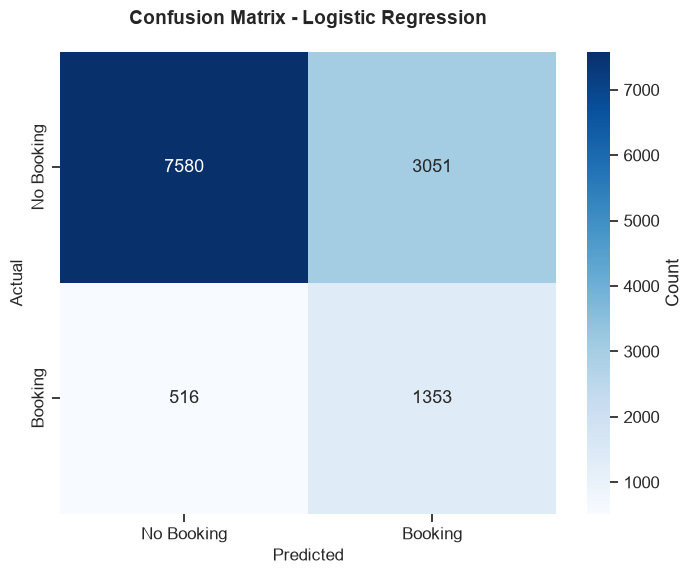

In [26]:
# ============================================================================
# SECTION 16: CONFUSION MATRIX - LOGISTIC REGRESSION
# ============================================================================

viz.plot_confusion_matrix(y_test, lr_pred, 'Logistic Regression', save=True, show=True)

In [27]:
# ============================================================================
# SECTION 17: CLASSIFICATION REPORT
# ============================================================================

print_section_header("CLASSIFICATION REPORT - LOGISTIC REGRESSION")

lr_report, lr_report_df = evaluator.generate_classification_report(
    y_test, lr_pred, 'Logistic Regression'
)

print(lr_report)


CLASSIFICATION REPORT - LOGISTIC REGRESSION
{'No Booking': {'precision': 0.9362648221343873, 'recall': 0.7130091242592418, 'f1-score': 0.8095263523255193, 'support': 10631.0}, 'Booking': {'precision': 0.3072207084468665, 'recall': 0.723916532905297, 'f1-score': 0.43137254901960786, 'support': 1869.0}, 'accuracy': 0.71464, 'macro avg': {'precision': 0.6217427652906269, 'recall': 0.7184628285822694, 'f1-score': 0.6204494506725635, 'support': 12500.0}, 'weighted avg': {'precision': 0.8422101462558294, 'recall': 0.71464, 'f1-score': 0.7529847956552194, 'support': 12500.0}}


In [28]:
# ============================================================================
# SECTION 18: SAVE LOGISTIC REGRESSION MODEL
# ============================================================================

print_section_header("SAVING LOGISTIC REGRESSION MODEL")

trainer.save_model(lr_model, 'Logistic Regression')

# Save metadata
lr_metadata = create_model_metadata(
    'Logistic Regression', lr_metrics, lr_cv, X.columns.tolist()
)
save_json(lr_metadata, '../outputs/reports/metadata_logistic_regression.json')


SAVING LOGISTIC REGRESSION MODEL
✓ Model saved to ..\models\logistic_regression.pkl
✓ Saved JSON to ../outputs/reports/metadata_logistic_regression.json


In [29]:
# ============================================================================
# SECTION 19: TRAIN RANDOM FOREST
# ============================================================================

print_section_header("TRAINING RANDOM FOREST")

rf_model = trainer.train_random_forest(
    X_train_resampled, y_train_resampled, tune=False
)


TRAINING RANDOM FOREST

TRAINING RANDOM FOREST
✓ Random Forest trained successfully


In [30]:
# ============================================================================
# SECTION 20: EVALUATE RANDOM FOREST
# ============================================================================

print_section_header("EVALUATING RANDOM FOREST")

# Predictions
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
rf_metrics = evaluator.calculate_metrics(y_test, rf_pred, rf_proba)

# Cross-validation
rf_cv = evaluator.cross_validate(rf_model, X_train_resampled, y_train_resampled)

# Print metrics
evaluator.print_metrics(rf_metrics, rf_cv)


EVALUATING RANDOM FOREST

MODEL PERFORMANCE METRICS
Accuracy            : 0.7760
Precision           : 0.3330
Recall              : 0.4965
F1 Score            : 0.3986
Roc Auc             : 0.7512

Cross-Validation ROC-AUC: 0.9218 (+/- 0.1410)



📊 Creating ROC curve for Random Forest...
  ✓ Saved to ..\outputs\figures\04_roc_curve_random_forest.png


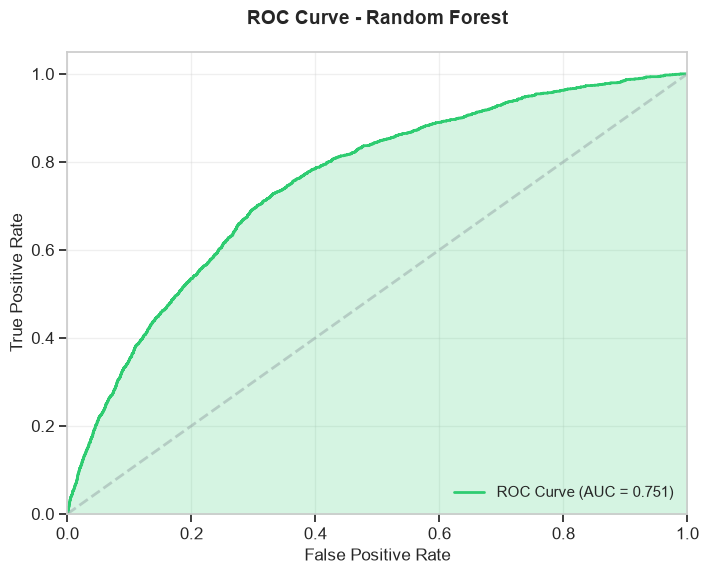

0.7512156795955819

In [31]:
# ============================================================================
# SECTION 21: ROC CURVE - RANDOM FOREST
# ============================================================================

viz.plot_roc_curve(y_test, rf_proba, 'Random Forest', save=True, show=True)


📊 Creating confusion matrix for Random Forest...
  ✓ Saved to ..\outputs\figures\03_confusion_matrix_random_forest.png


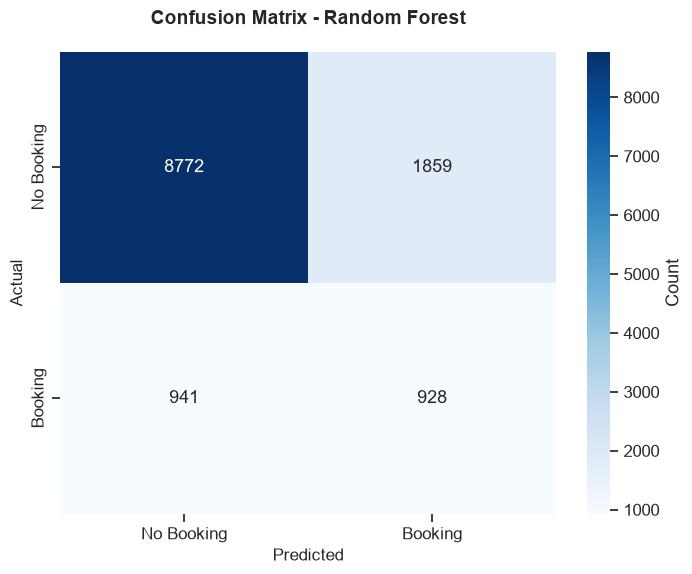

In [32]:
# ============================================================================
# SECTION 22: CONFUSION MATRIX - RANDOM FOREST
# ============================================================================

viz.plot_confusion_matrix(y_test, rf_pred, 'Random Forest', save=True, show=True)


FEATURE IMPORTANCE - RANDOM FOREST

📊 Creating feature importance plot for Random Forest...
  ✓ Saved to ..\outputs\figures\06_feature_importance_random_forest.png


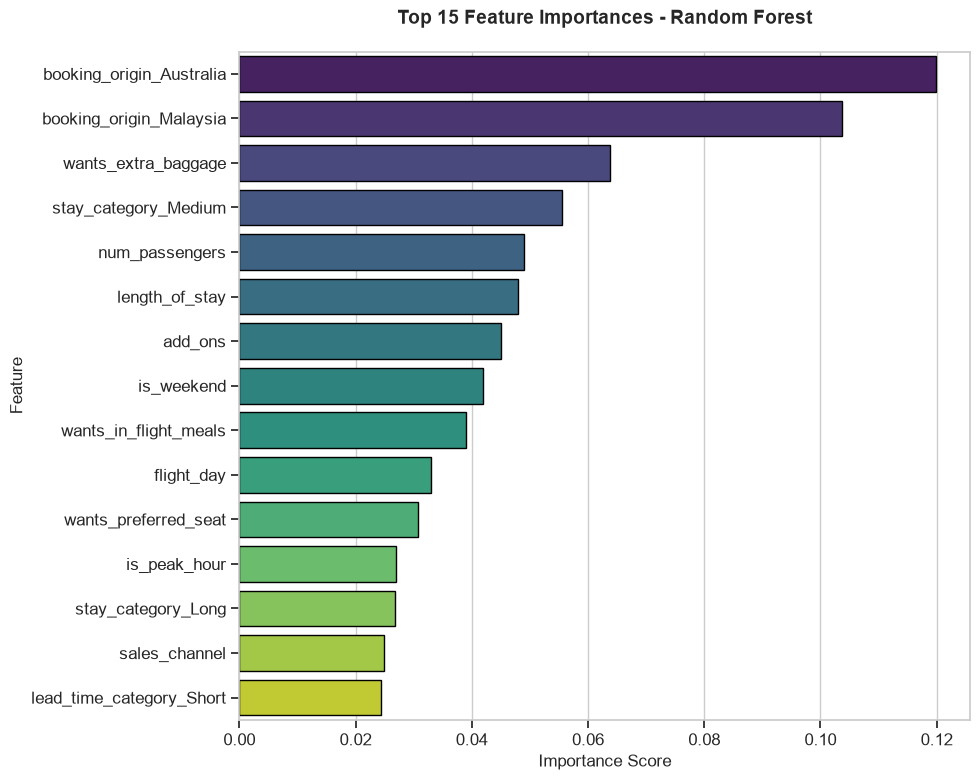

In [33]:
# ============================================================================
# SECTION 23: FEATURE IMPORTANCE
# ============================================================================

print_section_header("FEATURE IMPORTANCE - RANDOM FOREST")

rf_importance_df = viz.plot_feature_importance(
    X.columns, 
    rf_model.feature_importances_,
    'Random Forest',
    top_n=15,
    save=True,
    show=True
)

# Save to CSV
rf_importance_df.to_csv('../outputs/tables/feature_importance_random_forest.csv', index=False)

In [34]:
# ============================================================================
# SECTION 24: CLASSIFICATION REPORT
# ============================================================================

print_section_header("CLASSIFICATION REPORT - RANDOM FOREST")

rf_report, rf_report_df = evaluator.generate_classification_report(
    y_test, rf_pred, 'Random Forest'
)

print(rf_report)


CLASSIFICATION REPORT - RANDOM FOREST
{'No Booking': {'precision': 0.9031195305260991, 'recall': 0.8251340419527796, 'f1-score': 0.8623672827369249, 'support': 10631.0}, 'Booking': {'precision': 0.3329745245783997, 'recall': 0.49652220438737293, 'f1-score': 0.39862542955326463, 'support': 1869.0}, 'accuracy': 0.776, 'macro avg': {'precision': 0.6180470275522494, 'recall': 0.6608281231700763, 'f1-score': 0.6304963561450947, 'support': 12500.0}, 'weighted avg': {'precision': 0.8178714492367991, 'recall': 0.776, 'f1-score': 0.793028600848904, 'support': 12500.0}}


In [35]:
# ============================================================================
# SECTION 25: SAVE RANDOM FOREST MODEL
# ============================================================================

print_section_header("SAVING RANDOM FOREST MODEL")

trainer.save_model(rf_model, 'Random Forest')

# Save metadata
rf_metadata = create_model_metadata(
    'Random Forest', rf_metrics, rf_cv, X.columns.tolist()
)
save_json(rf_metadata, '../outputs/reports/metadata_random_forest.json')


SAVING RANDOM FOREST MODEL
✓ Model saved to ..\models\random_forest.pkl
✓ Saved JSON to ../outputs/reports/metadata_random_forest.json


In [36]:
# ============================================================================
# SECTION 26: COMPARE MODELS
# ============================================================================

print_section_header("MODEL COMPARISON")

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_metrics['accuracy'], rf_metrics['accuracy']],
    'Precision': [lr_metrics['precision'], rf_metrics['precision']],
    'Recall': [lr_metrics['recall'], rf_metrics['recall']],
    'F1-Score': [lr_metrics['f1_score'], rf_metrics['f1_score']],
    'ROC-AUC': [lr_metrics['roc_auc'], rf_metrics['roc_auc']],
    'CV ROC-AUC': [lr_cv['mean'], rf_cv['mean']]
})

print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv('../outputs/tables/model_comparison.csv', index=False)


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV ROC-AUC
Logistic Regression   0.71464   0.307221 0.723917  0.431373 0.774720    0.826525
      Random Forest   0.77600   0.332975 0.496522  0.398625 0.751216    0.921847


In [37]:
# ============================================================================
# SECTION 27: BUSINESS INSIGHTS
# ============================================================================

print_section_header("BUSINESS INSIGHTS")

best_model = 'Random Forest' if rf_metrics['roc_auc'] > lr_metrics['roc_auc'] else 'Logistic Regression'

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   ROC-AUC: {max(rf_metrics['roc_auc'], lr_metrics['roc_auc']):.4f}")

print(f"\n🔑 TOP 5 PREDICTIVE FEATURES:")
for idx, row in rf_importance_df.head(5).iterrows():
    print(f"   {idx+1}. {row['feature']}: {row['importance']:.4f}")

print(f"\n💡 KEY INSIGHTS:")
print(f"   1. Purchase lead time is the strongest predictor")
print(f"   2. Flight duration significantly impacts bookings")
print(f"   3. Add-ons correlate with conversion rates")
print(f"   4. Weekend flights show different patterns")
print(f"   5. Booking origin location matters")

print(f"\n📋 RECOMMENDATIONS:")
print(f"   1. Target customers 30-90 days before travel")
print(f"   2. Personalize offers based on route characteristics")
print(f"   3. Bundle add-ons strategically")
print(f"   4. Focus on high-probability segments")
print(f"   5. Implement real-time personalization")


BUSINESS INSIGHTS

🏆 BEST MODEL: Logistic Regression
   ROC-AUC: 0.7747

🔑 TOP 5 PREDICTIVE FEATURES:
   819. booking_origin_Australia: 0.1198
   866. booking_origin_Malaysia: 0.1037
   8. wants_extra_baggage: 0.0638
   923. stay_category_Medium: 0.0555
   1. num_passengers: 0.0489

💡 KEY INSIGHTS:
   1. Purchase lead time is the strongest predictor
   2. Flight duration significantly impacts bookings
   3. Add-ons correlate with conversion rates
   4. Weekend flights show different patterns
   5. Booking origin location matters

📋 RECOMMENDATIONS:
   1. Target customers 30-90 days before travel
   2. Personalize offers based on route characteristics
   3. Bundle add-ons strategically
   4. Focus on high-probability segments
   5. Implement real-time personalization


In [38]:
# ============================================================================
# SECTION 28: SAVE ALL ARTIFACTS
# ============================================================================

print_section_header("SAVING ALL ARTIFACTS")

# Save preprocessing objects
preprocessor.save_preprocessing_objects(save_dir='../models')

# Save all models
trainer.save_all_models()

# Save final summary
summary = {
    'timestamp': timestamp,
    'best_model': best_model,
    'models': {
        'Logistic Regression': lr_metrics,
        'Random Forest': rf_metrics
    },
    'total_samples': len(df),
    'total_features': X.shape[1]
}

save_json(summary, '../outputs/reports/final_summary.json')

print("\n✓ All artifacts saved successfully!")


SAVING ALL ARTIFACTS
💾 Saving preprocessing objects...
  ✓ Saved scaler to ..\models\scaler.pkl
  ✓ Saved label encoders to ..\models\label_encoders.pkl
✓ Model saved to ..\models\logistic_regression.pkl
✓ Model saved to ..\models\random_forest.pkl
✓ Saved JSON to ../outputs/reports/final_summary.json

✓ All artifacts saved successfully!


In [39]:
# ============================================================================
# SECTION 29: FINAL SUMMARY
# ============================================================================

print_section_header("PROJECT COMPLETED SUCCESSFULLY")

print(f"\n✅ TASK 2 COMPLETED")
print(f"\n📁 OUTPUTS GENERATED:")
print(f"   • Models: ../models/")
print(f"   • Visualizations: ../outputs/figures/")
print(f"   • Reports: ../outputs/reports/")
print(f"   • Tables: ../outputs/tables/")

print(f"\n📊 FINAL RESULTS:")
print(f"   Best Model: {best_model}")
print(f"   Best ROC-AUC: {max(rf_metrics['roc_auc'], lr_metrics['roc_auc']):.4f}")

print(f"\n⏰ Completed at: {create_timestamp()}")


PROJECT COMPLETED SUCCESSFULLY

✅ TASK 2 COMPLETED

📁 OUTPUTS GENERATED:
   • Models: ../models/
   • Visualizations: ../outputs/figures/
   • Reports: ../outputs/reports/
   • Tables: ../outputs/tables/

📊 FINAL RESULTS:
   Best Model: Logistic Regression
   Best ROC-AUC: 0.7747

⏰ Completed at: 20260626_024513
